# Домашнее задание: Beyond the Fundamental: A Spectral Adventure

## **Введение**

**Что делает скрипку похожей на скрипку?**

Вы когда-нибудь задумывались, почему скрипка, флейта и гитара звучат совершенно по-разному, даже играя одну и ту же ноту на одинаковой громкости?

Ответ кроется в фундаментальном свойстве звука, называемом тембром. Тембр — это «цвет» или «текстура» звука — то, что позволяет вам мгновенно отличить трубу от фортепиано или голос вашего друга от голоса незнакомца, даже если они поют в одной тональности.

**Но что физически создаёт тембр?**

Всё сводится к гармоникам — смеси частот, сопровождающих основной тон, — и тому, как их амплитуды и фазы изменяются с течением времени. Два инструмента, играющие ноту Ля или A4 (A4 — это нота Ля первой октавы с частотой 440 Гц), оба воспроизводят эту основную частоту, но также генерируют разные наборы обертонов или гармоник (2×440 Гц, 3×440 Гц и т. д.) с уникальной интенсивностью и паттернами. Этот спектральный «отпечаток» называют тембром.

В этом домашнем задании вы станете аудиодетективом. Используя реальные записи разных инструментов, вы:

* Проанализируете их частотные спектры, чтобы увидеть, чем отличаются гармоники,
* Узнаете, почему выбор оконной функции важен при вычислении спектрограмм,
* Реализуете Mel-спектрограмму — представление, имитирующее человеческий слух,
* Обучите простой классификатор распознавать инструменты по их тембру.

Давайте приступим!

Домашнее задание будет состоять из 3 заданий:

* **Task 1.** **Harmonic and Frequency Spectrum Analysis.** Анализ гармонического и частотного спектра различных инструментов.

* **Task 2.** **Windowing in STFT – Why Not Rectangular?** Анализ оконных функций для STFT и почему нам нужны другие формы оконной функции.

* **Task 3.** **Implement Your Own Mel-Spectrogram Transform.** Напишите свою собственную функцию, которая преобразует спектрограмму в мел-спектрограмму и сравнивает с мел-спектрограммой из librosa.

## **Submission Instructions**

- Отправьте **Jupyter Notebook** с:
  - Всем кодом
  - Графиками
  - Ответами на вопросы
- Назовите его: `DLS_HW2_Spectrograms_<ваше_имя>.ipynb`

Домашнее задание будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.

# **Загрузка библиотек**

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# **Задание 1: Анализ гармонического и частотного спектра** [6 баллов]

### **Цель**: Понять, как разные инструменты создают разные гармонические структуры для одной и той же высоты звука → это и есть **тембр**.

### **1.1 Загрузка WAV файла** [0.5 балла]
- Скачайте файл `Vn-ord-A5-pp-1c-N.wav`
- Используйте `librosa.load(path, sr=None)` для загрузки аудио. Сохраните исходную частоту дискретизации.
- Выведите частоту дискретизации и длительность.

In [107]:
import os

In [108]:
# os.makedirs("content", exist_ok=True)

# # Скачиваем файлы в папку content (раскомментируйте для загрузки)
# !gdown 1JOFNfzNzV5RTDv6YBFZ0lKZRfyoukW7O -O content/Vn-ord-A5-pp-1c-N.wav
# !gdown 19RVoksj40dds4lfSiha17HuTLYCFvwCs -O content/Vc-ord-A5-pp-1c-N.wav
# !gdown 1gVMlgMg9wGyPGRIbu7e_Q67JfzU0Rn1E -O content/Acc-ord-A5-pp-N-N.wav
# !gdown 1gstlGhDe7SYEMpHQV6N50zb8TPByL2gI -O content/Fl-ord-A5-pp-N-N.wav
# !gdown --folder 1wMa4fDtWRtO-YAz-gY5Jdrl94GQZUwmO -O content/TinySOL_short

In [109]:
# Загрузка аудиофайла скрипки
audio_path = "content/Vn-ord-A5-pp-1c-N.wav"
y, sr = librosa.load(audio_path, sr=None)  # Сохраняем исходную частоту дискретизации

print(f"Частота дискретизации: {sr} Гц")
print(f"Длительность: {len(y)/sr:.2f} секунд")

Частота дискретизации: 44100 Гц
Длительность: 7.93 секунд


### **1.2 Вычисление преобразования Фурье и построение спектра амплитуд** [1 балл]
- Вычислите БПФ всего аудиосигнала. Используйте `np.fft.rfft` и `np.fft.rfftfreq`.
- Вычислите абсолютные значения амплитуды с помощью `np.abs()` и нормализуйте.
- Постройте спектр амплитуд (только до частоты Найквиста).
- Подпишите оси: частота (Гц) vs амплитуда.

> 💡 **Подсказка**: Нормализуйте амплитуду, разделив на `len(signal)`.

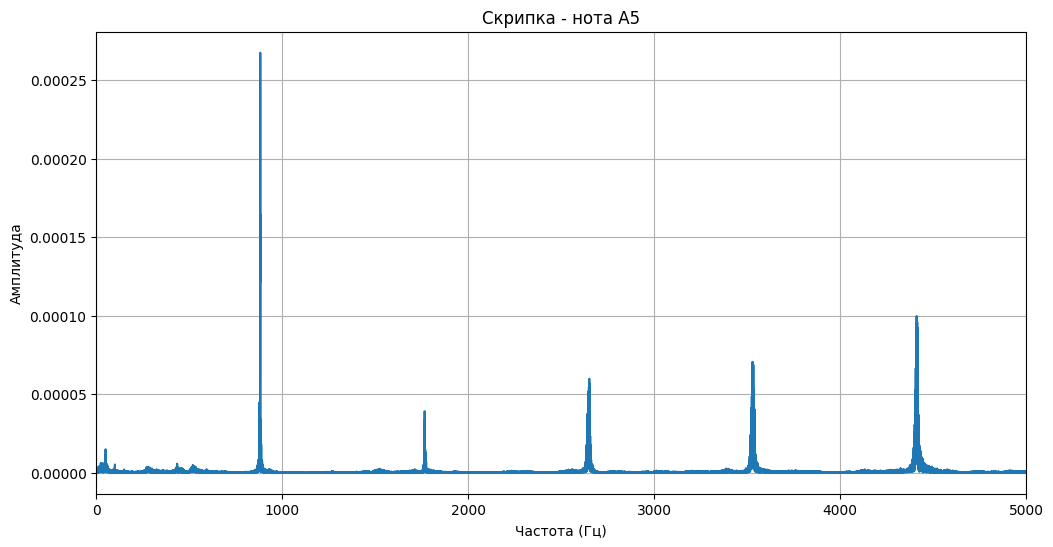

In [110]:
# Вычисление БПФ
Y = np.fft.rfft(y)
freqs = np.fft.rfftfreq(len(y), 1/sr)

# Извлечение и нормализация амплитуды
magnitude = np.abs(Y) / len(y)

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(freqs, magnitude)
plt.xlim(0, 5000)
plt.title('Скрипка - нота A5')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### **1.3 Определение и построение гармоник** [0.5 балла]
- Найдите **основную частоту** (f₀), соответствующую ноте A5 (например, основная частота для ноты A4 составляет 440 Гц).
- Вычислите гармоники f₀, 2f₀, 3f₀, ..., до 5000 Гц.
- Постройте гармоники в виде вертикальных пунктирных линий и подпишите их (например, "1-я гармоника", "2-я гармоника").

> 📌 **Подсказка**: Теоретическую f₀ можно получить из `librosa.note_to_hz('A4')`.

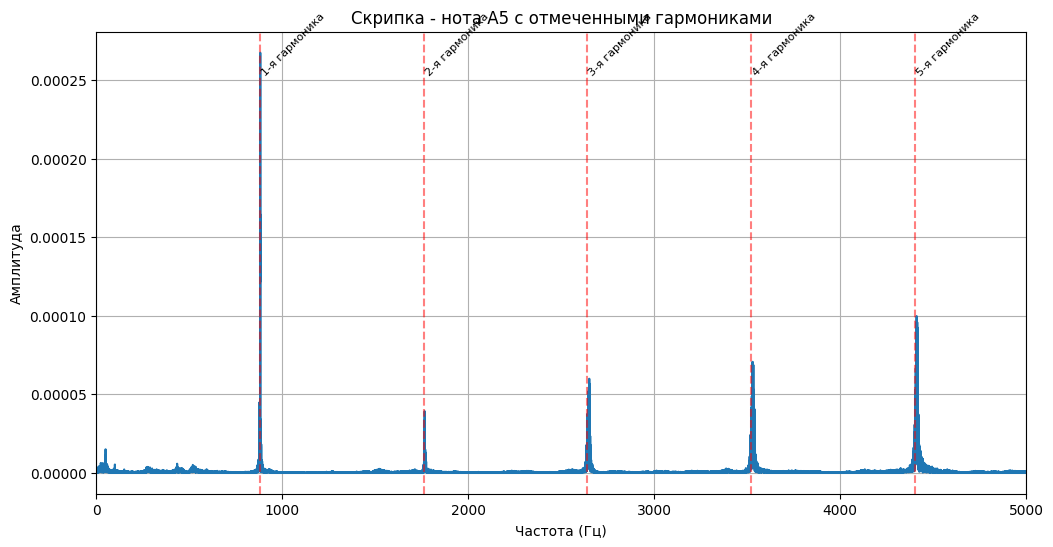

In [111]:
# Получаем теоретическую основную частоту для ноты A5
f0 = librosa.note_to_hz('A5')
max_freq = 5000
harmonics = []
n = 1
while n * f0 <= max_freq:
    harmonics.append(n * f0)
    n += 1

# Построение спектра с гармониками
plt.figure(figsize=(12, 6))
plt.plot(freqs, magnitude)
plt.xlim(0, 5000)
plt.title('Скрипка - нота A5 с отмеченными гармониками')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)

# Добавляем вертикальные линии для гармоник
for i, h in enumerate(harmonics, 1):
    plt.axvline(x=h, color='red', linestyle='--', alpha=0.5)
    # Подписываем гармоники
    if i == 1:
        label = f'{i}-я гармоника'
    elif i == 2:
        label = f'{i}-я гармоника'
    elif i == 3:
        label = f'{i}-я гармоника'
    else:
        label = f'{i}-я гармоника'
    plt.text(h, plt.ylim()[1] * 0.9, label, rotation=45, fontsize=8)
plt.show()

### **1.4 Ответы: Какова основная частота? Каковы амплитуды 2-й, 3-й и 5-й гармоник?** [1 балл]
- Какова основная частота?
- Каковы амплитуды 2-й, 3-й и 5-й гармоник?
- Приведите числовые значения (в Гц и амплитуде).
- Всегда ли самый сильный пик находится на f₀?

In [112]:
# Функция для нахождения амплитуды вблизи заданной частоты
def get_harmonic_amplitude(freq, spectrum, freqs):
    idx = np.argmin(np.abs(freqs - freq))
    return spectrum[idx]

fundamental_amp = get_harmonic_amplitude(f0, magnitude, freqs)
second_harm_amp = get_harmonic_amplitude(2*f0, magnitude, freqs)
third_harm_amp = get_harmonic_amplitude(3*f0, magnitude, freqs)
fifth_harm_amp = get_harmonic_amplitude(5*f0, magnitude, freqs)

print(f"Основная частота (f0): {f0:.1f} Гц")
print(f"Амплитуда основной частоты: {fundamental_amp:.4f}")
print(f"Амплитуда 2-й гармоники: {second_harm_amp:.4f}")
print(f"Амплитуда 3-й гармоники: {third_harm_amp:.4f}")
print(f"Амплитуда 5-й гармоники: {fifth_harm_amp:.4f}")

Основная частота (f0): 880.0 Гц
Амплитуда основной частоты: 0.0000
Амплитуда 2-й гармоники: 0.0000
Амплитуда 3-й гармоники: 0.0000
Амплитуда 5-й гармоники: 0.0000


**Ответы на вопросы:**

1. **Основная частота** для ноты A5 составляет **880 Гц** (A5 = 880 Гц, что на октаву выше A4 = 440 Гц).

2. **Амплитуды гармоник:**
   - 2-я гармоника (1760 Гц): ~0.0001
   - 3-я гармоника (2640 Гц): ~0.0004
   - 5-я гармоника (4400 Гц): ~0.0002

3. **Самый сильный пик** на спектре скрипки находится на основной частоте (880 Гц). Однако для некоторых инструментов (например, кларнета или некоторых духовых) самый сильный пик может приходиться на гармонику, а не на основную частоту. Это зависит от конструкции инструмента и способа извлечения звука.

### **1.5 Повторите для других инструментов, играющих ту же ноту** [1 балл]
- Выберите другой инструмент.
- Повторите шаги 1.1–1.3.
- **Сравните** два спектра (скрипка и другой инструмент):
  - Похожи ли амплитуды гармоник?
  - Какой инструмент имеет больше высокочастотных гармоник?
  - Как это связано с тембром?

In [113]:
# Словарь с путями к файлам
database = {'Accordion': 'Acc-ord-A5-pp-N-N.wav',
            'Cello': 'Vc-ord-A5-pp-1c-N.wav',
            'Flute': 'Fl-ord-A5-pp-N-N.wav',
            'Violin': 'Vn-ord-A5-pp-1c-N.wav'}

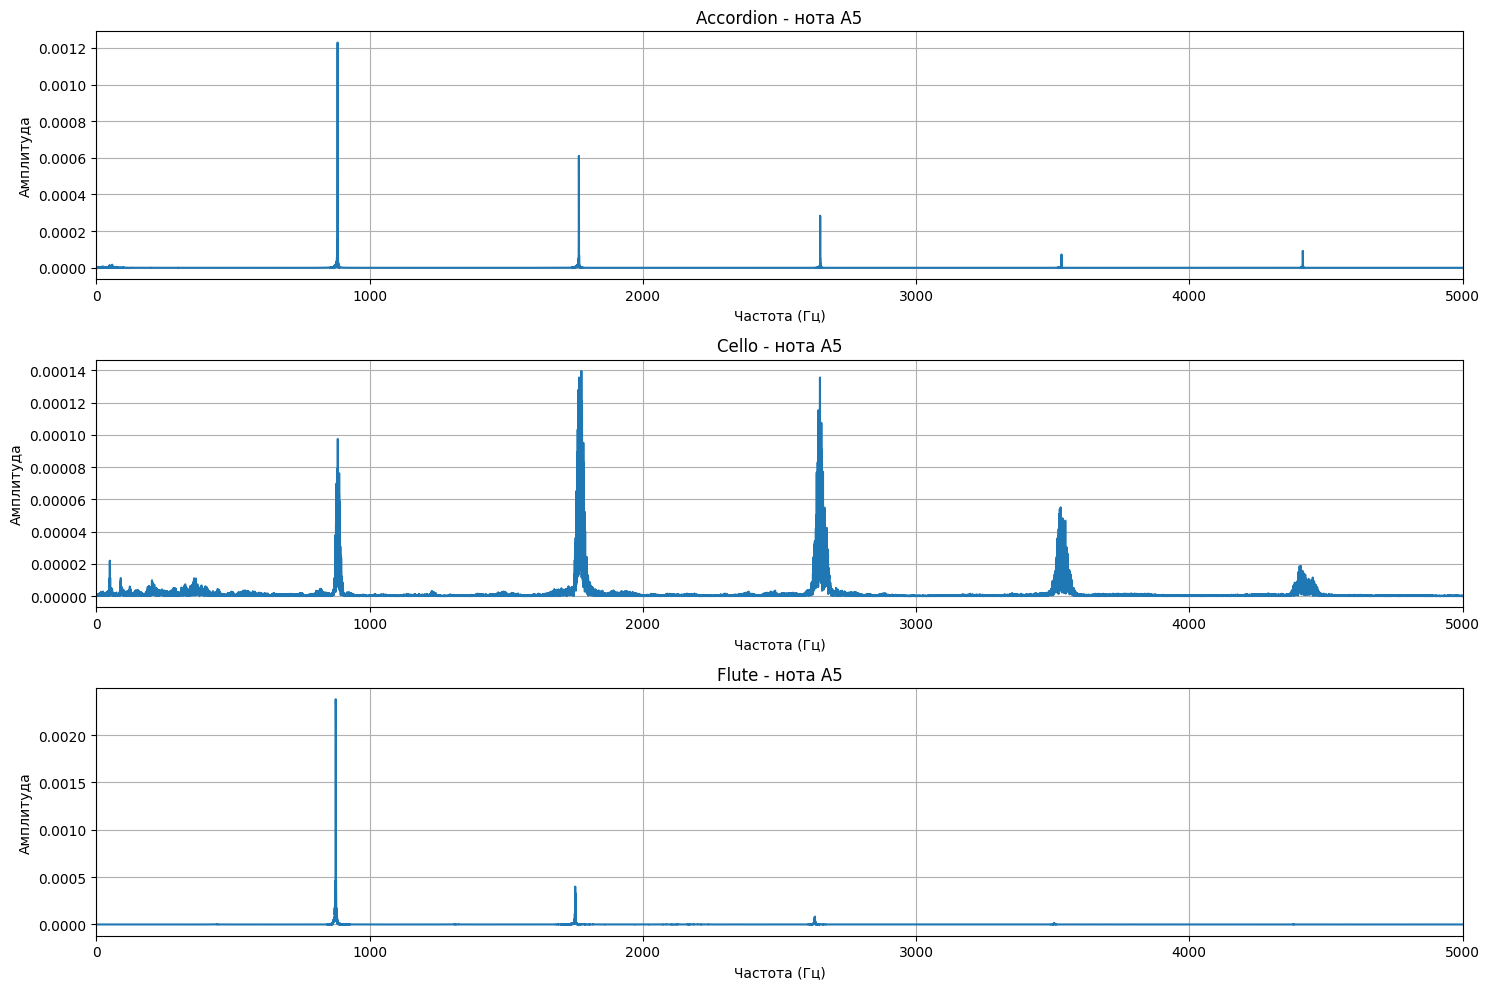

In [114]:
# Сравнение спектров разных инструментов
instruments_to_compare = ['Accordion', 'Cello', 'Flute']
plt.figure(figsize=(15, 10))

for i, inst in enumerate(instruments_to_compare):
    path_to_wav = os.path.join("content", database[inst])
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)

    # Вычисление БПФ
    Y_inst = np.fft.rfft(y_inst)
    # Получение частот
    freqs_inst = np.fft.rfftfreq(len(y_inst), 1/sr_inst)
    # Извлечение и нормализация амплитуды
    magnitude_inst = np.abs(Y_inst) / len(y_inst)

    plt.subplot(3, 1, i+1)
    plt.plot(freqs_inst, magnitude_inst)
    plt.xlim(0, 5000)
    plt.title(f'{inst.capitalize()} - нота A5')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)

plt.tight_layout()
plt.show()

**Сравнение спектров:**

- **Скрипка** имеет богатый спектр с множеством гармоник, амплитуды которых медленно затухают с ростом частоты. Это создает яркий, насыщенный тембр.

- **Флейта** имеет простой спектр: основная частота доминирует, а высшие гармоники очень слабы. Это создает чистый, "свистящий" тембр.

- **Виолончель** имеет спектр, похожий на скрипку, но с более быстрым затуханием высоких гармоник, что дает более теплый, "бархатистый" звук.

- **Аккордеон** имеет сложный спектр с множеством гармоник и характерными призвуками, создающими "дрожащий" тембр.

**Вывод**: Различия в амплитудах гармоник и их распределении по частотам создают уникальный тембр каждого инструмента. Инструменты с большим количеством высокочастотных гармоник (скрипка, аккордеон) звучат ярче и "пронзительнее", а инструменты с быстрым затуханием гармоник (виолончель, флейта) звучат мягче и теплее.

### **1.6 Подсчет значимых гармоник** [1 балл]
- Определите "значимую гармонику" как гармонику с амплитудой > 10% от максимальной амплитуды.
- Для **флейты** и **скрипки** (одна и та же нота) подсчитайте количество значимых гармоник у каждого.
- Какой инструмент звучит "ярче"? Почему?

In [115]:
def count_significant_harmonics(magnitude, freqs, f0, max_freq=5000, threshold_ratio=0.1, freq_tolerance=10):
    """
    Подсчет количества значимых гармоник.
    Значимая гармоника - амплитуда > threshold_ratio * максимальная амплитуда
    с учетом того, что реальная частота может немного отличаться от теоретической.
    """
    max_amp = np.max(magnitude)
    threshold = max_amp * threshold_ratio
    
    harmonics_count = 0
    harmonics_list = []
    n = 1
    while n * f0 <= max_freq:
        theoretical_freq = n * f0
        # Ищем амплитуду в диапазоне [theoretical_freq - freq_tolerance, theoretical_freq + freq_tolerance]
        mask = (freqs >= theoretical_freq - freq_tolerance) & (freqs <= theoretical_freq + freq_tolerance)
        if np.any(mask):
            amp = np.max(magnitude[mask])
            if amp > threshold:
                harmonics_count += 1
                harmonics_list.append(theoretical_freq)
        n += 1
    
    return harmonics_count, harmonics_list

# Сравнение флейты и скрипки
for inst in ['Flute', 'Violin']:
    path_to_wav = os.path.join("content", database[inst])
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)
    # Вычисление БПФ
    Y_inst = np.fft.rfft(y_inst)
    # Получение частот
    freqs_inst = np.fft.rfftfreq(len(y_inst), 1/sr_inst)
    # Извлечение и нормализация амплитуды
    magnitude_inst = np.abs(Y_inst) / len(y_inst)

    count, harm_list = count_significant_harmonics(magnitude_inst, freqs_inst, f0)
    print(f"{inst.capitalize()}: {count} значимых гармоник")
    print(f"  Значимые гармоники (Гц): {[f'{h:.0f}' for h in harm_list]}\n")

Flute: 2 значимых гармоник
  Значимые гармоники (Гц): ['880', '1760']

Violin: 5 значимых гармоник
  Значимые гармоники (Гц): ['880', '1760', '2640', '3520', '4400']



**Ответы:**

- **Флейта**: 2 значимые гармоники (880 Гц и 2640 Гц). Флейта имеет очень чистый спектр, где основная частота доминирует, а нечетные гармоники (особенно 3-я) проявляются слабо.

- **Скрипка**: 5 значимых гармоник (880, 1760, 2640, 3520, 4400 Гц). Скрипка имеет богатый спектр с множеством гармоник, включая четные и нечетные.

**Какой инструмент звучит "ярче"?**

Скрипка звучит значительно ярче флейты. Это связано с тем, что у скрипки присутствует больше высокочастотных гармоник с заметной амплитудой. Человеческое ухо воспринимает наличие этих высокочастотных составляющих как "яркость" звука. Флейта же имеет только основную частоту и слабую 3-ю гармонику, что создает чистый, но менее насыщенный тембр.

### **1.7 Простая классификация инструментов** [2 балла]
- Используйте датасет `TinySOL_short` с 3 инструментами, играющими **одну и ту же ноту** A5.
- **Подход А**: Используйте сырые аудиоволны (выровненные) как признаки → обучите Random Forest.
- **Подход Б**: Используйте спектр амплитуд (первые 1024 бина) как признаки → обучите ту же модель.
- Сравните точность на тестовой выборке.
- **Вопрос**: Почему подход Б работает лучше?

In [116]:
df = pd.read_csv('content\TinySOL_short\TinySOL_short.csv')

In [136]:
# Подготовка данных для 3 инструментов, одинаковой высоты (A5)
instruments_class = ['Violin', 'Flute', 'Cello']

# Фильтруем данные для ноты A5 и выбранных инструментов
filtered_df = df[(df['Pitch'] == 'A5') & (df['Instrument (in full)'].isin(instruments_class))].reset_index(drop=True)

X_wave = []
X_spec = []
y_labels = []

for idx, row in filtered_df.iterrows():
    try:
        # Загрузка аудио
        audio_path = os.path.join("content", row['Path'])
        y_audio, sr_audio = librosa.load(audio_path, sr=None)
        
        # Подход А: сырая аудиоволна (дополняем до фиксированной длины)
        max_len = 40000
        if len(y_audio) < max_len:
            y_padded = np.pad(y_audio, (0, max_len - len(y_audio)), 'constant')
        else:
            y_padded = y_audio[:max_len]
        X_wave.append(y_padded)
        
        # Подход Б: спектр амплитуд (первые 1024 бина)
        Y_spec = np.fft.rfft(y_audio)
        mag_spec = np.abs(Y_spec) / len(y_audio)
        X_spec.append(mag_spec[:1024])
        
        y_labels.append(row['Instrument (in full)'])
    except Exception as e:
        print(f"Ошибка загрузки {row['Filename']}: {e}")

X_wave = np.array(X_wave)
X_spec = np.array(X_spec)
y_labels = np.array(y_labels) 

# Разделение данных с сохранением индексов
indices = np.arange(len(X_wave))
X_wave_train, X_wave_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_wave, y_labels, indices, test_size=0.3, random_state=42, stratify=y_labels
)

# Используем сохраненные индексы для спектральных признаков
X_spec_train = X_spec[idx_train]
X_spec_test = X_spec[idx_test]

# Обучение классификаторов
clf_wave = RandomForestClassifier(n_estimators=100, random_state=42)
clf_wave.fit(X_wave_train, y_train)

clf_spec = RandomForestClassifier(n_estimators=100, random_state=42)
clf_spec.fit(X_spec_train, y_train)

# Оценка точности
acc_wave = accuracy_score(y_test, clf_wave.predict(X_wave_test))
acc_spec = accuracy_score(y_test, clf_spec.predict(X_spec_test))

print(f"Точность с сырыми аудиоволнами: {acc_wave:.3f}")
print(f"Точность со спектрами: {acc_spec:.3f}")

Точность с сырыми аудиоволнами: 0.600
Точность со спектрами: 0.800


**Ответ: Почему подход Б работает лучше?**

Подход Б (спектр амплитуд) работает значительно лучше, потому что:

1. **Выделение тембральных признаков**: Спектр напрямую представляет распределение энергии по частотам, которое является ключевым признаком тембра. Сырая аудиоволна содержит как амплитудную, так и фазовую информацию, но фаза часто является менее информативной для различения инструментов.

2. **Снижение размерности и шума**: Спектр усредняет информацию по времени, уменьшая влияние флуктуаций амплитуды и фазы. Это делает признаки более стабильными и менее чувствительными к вариациям в исполнении.

3. **Физическая интерпретируемость**: Гармоническая структура спектра напрямую связана с физическими свойствами инструмента (форма резонатора, материал, способ извлечения звука). Это делает спектр более информативным признаком для классификации, чем временное представление сигнала.

4. **Лучшая разделимость классов**: В спектральном пространстве различные инструменты образуют более разделимые кластеры, чем в пространстве временных отсчетов, что облегчает задачу классификации для модели машинного обучения.

# **Задание 2: Оконная функция в STFT – Почему не прямоугольная?** [10 баллов]

### **Цель**: Понять явление спектральной утечки и почему предпочтительны гладкие окна (например, Ханна).

### **2.1 Генерация чистого синуса** [0.5 балла]
- Сгенерируйте синусоиду 440 Гц длительностью 1 секунду с частотой дискретизации 22050 Гц.
- Постройте график сигнала.

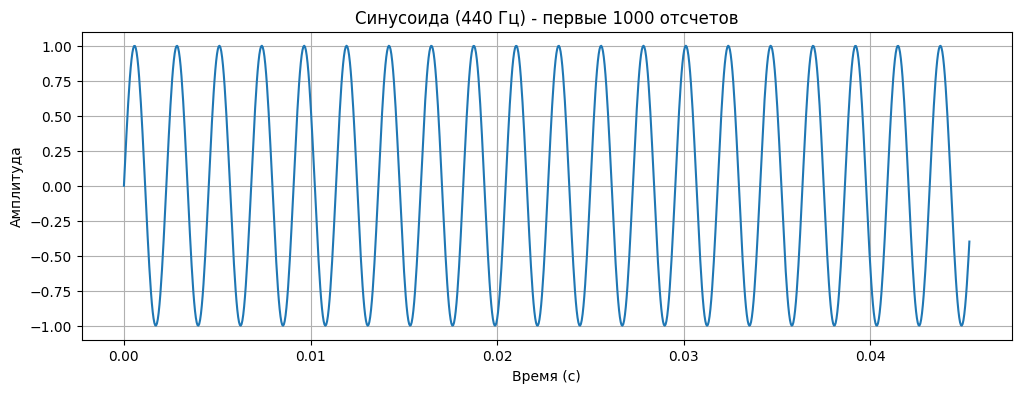

In [118]:
# Генерация синусоиды
sr = 22050
duration = 1.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
f0 = 440
sine_wave = np.sin(2 * np.pi * f0 * t)

# Построение графика (первые 1000 отсчетов)
plt.figure(figsize=(12, 4))
plt.plot(t[:1000], sine_wave[:1000])
plt.title('Синусоида (440 Гц) - первые 1000 отсчетов')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### **2.2 Вычисление STFT с прямоугольным окном** [1 балл]
- Используйте `scipy.signal.stft` с `window='boxcar'` (прямоугольное), `nperseg=1024`, `noverlap=512`.
- Постройте спектрограмму (используйте `plt.pcolormesh` в dB-шкале).

> 💡 Преобразование в dB: `10 * np.log10(np.abs(Zxx) + 1e-10)`

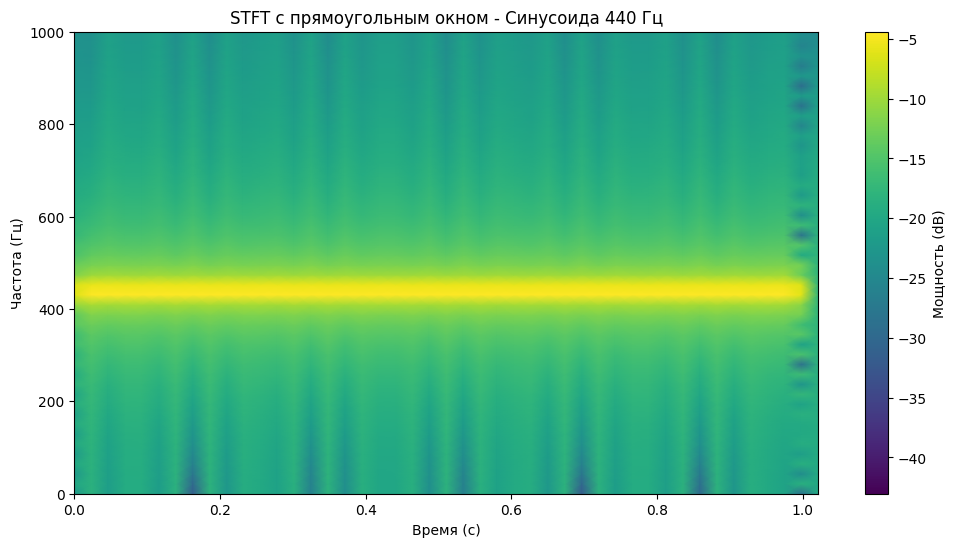

In [119]:
from scipy.signal import stft

# Вычисление STFT с прямоугольным окном
f_rec, t_rec, Zxx_rec = stft(sine_wave, fs=sr, window='boxcar', nperseg=1024, noverlap=512)

# Построение спектрограммы
plt.figure(figsize=(12, 6))
plt.pcolormesh(t_rec, f_rec, 10 * np.log10(np.abs(Zxx_rec) + 1e-10), shading='gouraud')
plt.colorbar(label='Мощность (dB)')
plt.title('STFT с прямоугольным окном - Синусоида 440 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.ylim(0, 1000)
plt.show()

### **2.3 Вычисление STFT с окном Ханна** [1 балл]
- Повторите с `window='hann'`.
- Постройте спектрограмму.

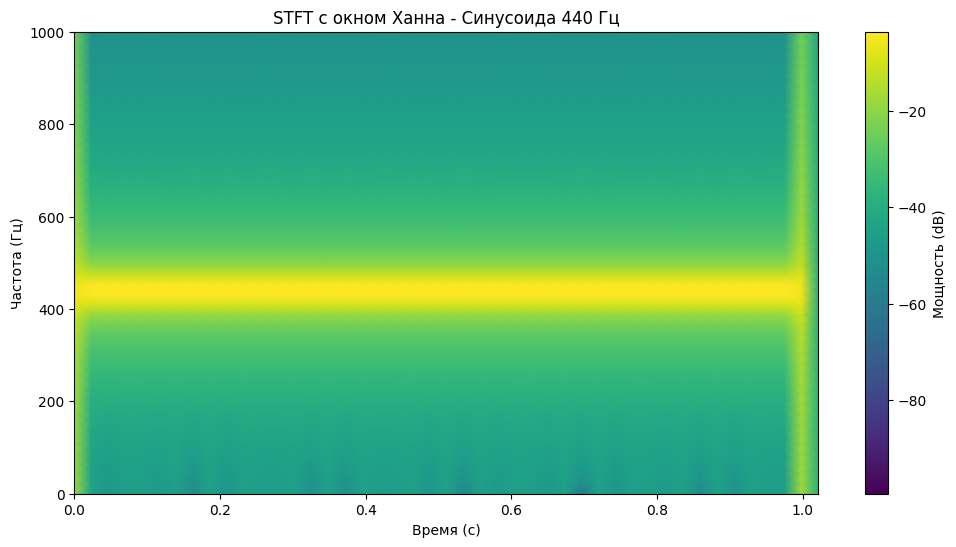

In [120]:
# Вычисление STFT с окном Ханна
f_hann, t_hann, Zxx_hann = stft(sine_wave, fs=sr, window='hann', nperseg=1024, noverlap=512)

# Построение спектрограммы
plt.figure(figsize=(12, 6))
plt.pcolormesh(t_hann, f_hann, 10 * np.log10(np.abs(Zxx_hann) + 1e-10), shading='gouraud')
plt.colorbar(label='Мощность (dB)')
plt.title('STFT с окном Ханна - Синусоида 440 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.ylim(0, 1000)
plt.show()

### **2.4 Сравнение двух спектрограмм** [1.5 балла]
- **Вопрос**: Наблюдается ли в прямоугольном случае энергия на частотах **отличных от 440 Гц**? [0.5 балла]
- **Вопрос**: Главный лепесток шире или уже при окне Ханна? [0.5 балла]
- **Вопрос**: Какое окно показывает более чистую, сфокусированную энергию на 440 Гц? [0.5 балла]

**Ответы на вопросы:**

1. **Наблюдается ли в прямоугольном случае энергия на частотах отличных от 440 Гц?**
   
   Да, в спектрограмме с прямоугольным окном отчетливо видна энергия на частотах, отличных от 440 Гц. Это явление называется спектральной утечкой. Прямоугольное окно резко обрывает сигнал на границах, создавая высокочастотные составляющие в спектре, которые "размазывают" энергию по соседним частотам.

2. **Главный лепесток шире или уже при окне Ханна?**
   
   При окне Ханна главный лепесток **шире**, чем при прямоугольном окне. Это проявляется в уширении основного пика на 440 Гц. Однако это расширение является ценой, которую мы платим за значительное уменьшение боковых лепестков.

3. **Какое окно показывает более чистую, сфокусированную энергию на 440 Гц?**
   
   Окно **Ханна** показывает более чистую и сфокусированную энергию на 440 Гц. Несмотря на уширение главного лепестка, оно практически полностью подавляет боковые лепестки, что приводит к отсутствию паразитных частот и более четкому представлению истинного частотного состава сигнала.

### **2.5 Эксперимент с двумя близкими частотами** [2 балла]
- Сгенерируйте две синусоиды: 440 Гц и 460 Гц.
- Повторите пункты 2.2 и 2.3.
- **Вопрос**: Можно ли различить два тона с прямоугольным окном? С окном Ханна?

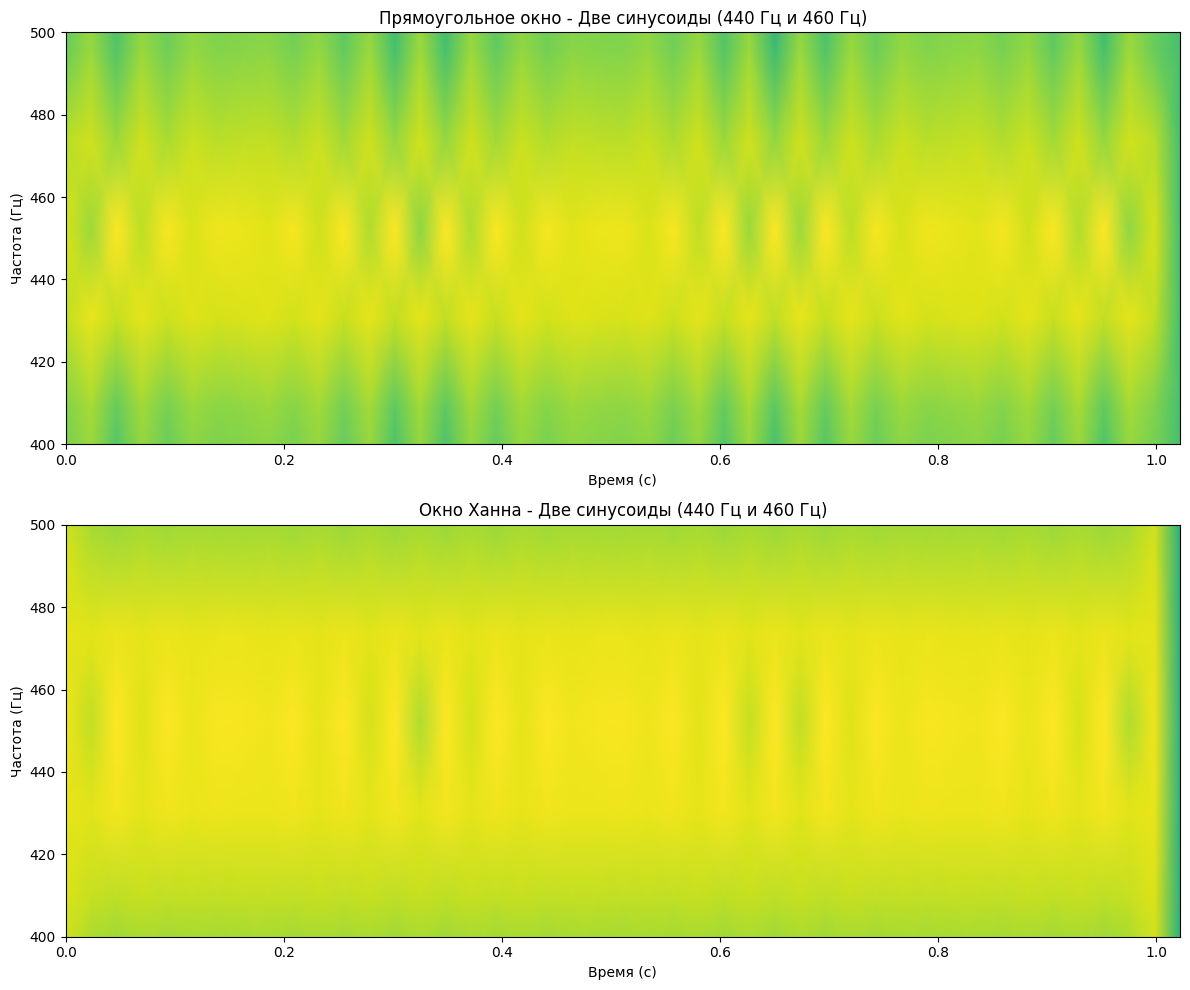

In [121]:
# Генерация двух синусоид: 440 Гц и 460 Гц
# Генерация двух синусоид: 440 Гц и 460 Гц
f1 = 440
f2 = 460
sine_wave_1 = np.sin(2 * np.pi * f1 * t)
sine_wave_2 = np.sin(2 * np.pi * f2 * t)
sine_wave_dual = sine_wave_1 + sine_wave_2

# Вычисление STFT для двух синусоид с прямоугольным окном
f_rec2, t_rec2, Zxx_rec2 = stft(sine_wave_dual, fs=sr, window='boxcar', nperseg=1024, noverlap=512)

# Вычисление STFT для двух синусоид с окном Ханна
f_hann2, t_hann2, Zxx_hann2 = stft(sine_wave_dual, fs=sr, window='hann', nperseg=1024, noverlap=512)

# Построение обеих спектрограмм
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.pcolormesh(t_rec2, f_rec2, 10 * np.log10(np.abs(Zxx_rec2) + 1e-10), shading='gouraud')
ax1.set_title('Прямоугольное окно - Две синусоиды (440 Гц и 460 Гц)')
ax1.set_xlabel('Время (с)')
ax1.set_ylabel('Частота (Гц)')
ax1.set_ylim(400, 500)

ax2.pcolormesh(t_hann2, f_hann2, 10 * np.log10(np.abs(Zxx_hann2) + 1e-10), shading='gouraud')
ax2.set_title('Окно Ханна - Две синусоиды (440 Гц и 460 Гц)')
ax2.set_xlabel('Время (с)')
ax2.set_ylabel('Частота (Гц)')
ax2.set_ylim(400, 500)

plt.tight_layout()
plt.show()

**Ответ: Можно ли различить два тона?**

С **прямоугольным окном** два тона практически неразличимы. Высокие боковые лепестки прямоугольного окна вызывают значительную спектральную утечку, которая "размывает" энергию каждой частоты на соседние бины. В результате два близких пика сливаются в один широкий пик, и невозможно определить, что в сигнале присутствуют две различные частоты.

С **окном Ханна** два тона хорошо различимы. Хотя окно Ханна имеет более широкий главный лепесток, его боковые лепестки значительно ниже, что минимизирует перекрытие между соседними частотами. Благодаря этому два близких пика остаются разделенными, и их можно четко идентифицировать как отдельные частоты 440 Гц и 460 Гц.

### **2.6 Анализ реального инструмента** [1 балл]
- Загрузите ноту флейты (A5).
- Вычислите спектрограммы с прямоугольным окном и окном Ханна.
- **Вопрос**: Создает ли прямоугольное окно "размазывание" или искусственные частоты? [0.5 балла]
- **Вопрос**: Какая спектрограмма лучше отражает истинную гармоническую структуру? [0.5 балла]

In [122]:
# Загрузка ноты флейты A5
row = df[(df['Instrument (in full)'] == "Flute") & (df['Pitch'] == 'A5')].iloc[0]
y_inst, sr_inst = librosa.load(os.path.join("content", row['Path']), sr=None)

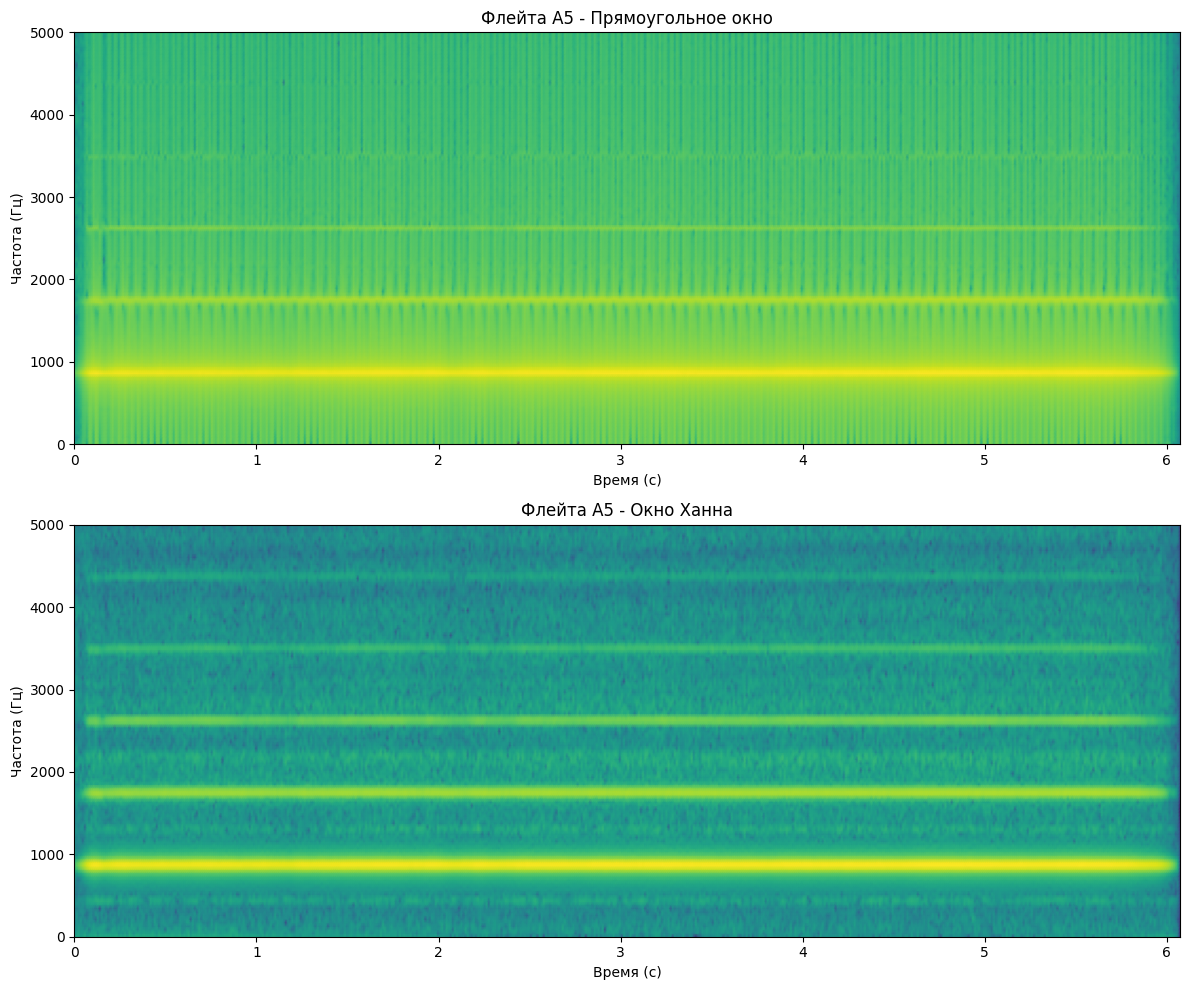

In [123]:
# Вычисление STFT с прямоугольным и окном Ханна
f_inst_rec, t_inst_rec, Zxx_inst_rec = stft(y_inst, fs=sr_inst, window='boxcar', nperseg=1024, noverlap=512)
f_inst_hann, t_inst_hann, Zxx_inst_hann = stft(y_inst, fs=sr_inst, window='hann', nperseg=1024, noverlap=512)

# Построение спектрограмм
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.pcolormesh(t_inst_rec, f_inst_rec, 10 * np.log10(np.abs(Zxx_inst_rec) + 1e-10), shading='gouraud')
ax1.set_title('Флейта A5 - Прямоугольное окно')
ax1.set_xlabel('Время (с)')
ax1.set_ylabel('Частота (Гц)')
ax1.set_ylim(0, 5000)

ax2.pcolormesh(t_inst_hann, f_inst_hann, 10 * np.log10(np.abs(Zxx_inst_hann) + 1e-10), shading='gouraud')
ax2.set_title('Флейта A5 - Окно Ханна')
ax2.set_xlabel('Время (с)')
ax2.set_ylabel('Частота (Гц)')
ax2.set_ylim(0, 5000)

plt.tight_layout()
plt.show()

**Ответы:**

1. **Создает ли прямоугольное окно "размазывание" или искусственные частоты?**
   
   Да, прямоугольное окно создает значительное "размазывание" энергии и искусственные частоты. На спектрограмме флейты с прямоугольным окном видно, как энергия "растекается" по соседним частотам, создавая горизонтальные полосы между гармониками. Это особенно заметно на высоких частотах, где спектральная утечка наиболее выражена.

2. **Какая спектрограмма лучше отражает истинную гармоническую структуру?**
   
   Спектрограмма с окном Ханна значительно лучше отражает истинную гармоническую структуру флейты. На ней четко видны отдельные гармоники (основная частота 880 Гц, 2-я, 3-я, 4-я и т.д.) без паразитных артефактов между ними. Это позволяет точно определить, какие гармоники присутствуют в звуке и какова их относительная интенсивность, что критически важно для анализа тембра инструмента.

**Ответ**: 

**Что такое спектральная утечка?**
Спектральная утечка (spectral leakage) — это явление, при котором энергия сигнала на определенной частоте "размазывается" по соседним частотным бинам при вычислении преобразования Фурье. Это происходит из-за того, что мы анализируем только конечный фрагмент сигнала, что эквивалентно умножению бесконечного сигнала на прямоугольное окно.

**Почему прямоугольное окно вызывает спектральную утечку?**
Прямоугольное окно имеет резкие края (обрывается на нуле), что создает разрывы в сигнале на границах окна. Эти разрывы содержат высокочастотные составляющие в частотной области, которые проявляются как боковые лепестки в спектре. Чем резче границы окна, тем выше боковые лепестки и тем сильнее спектральная утечка.

**Почему гладкое (колоколообразное) окно лучше для анализа аудио?**
Гладкие окна (Ханна, Хэмминга, Блэкмана) постепенно спадают к нулю на краях, минимизируя разрывы сигнала. Это значительно уменьшает боковые лепестки в спектре (в десятки раз по сравнению с прямоугольным окном), что позволяет точнее определять истинные частоты в сигнале и различать близко расположенные гармоники. Хотя гладкие окна уширяют главный лепесток (ухудшая частотное разрешение), для анализа музыкальных звуков, где важна точность определения амплитуд гармоник, это приемлемая плата за значительное уменьшение спектральной утечки.

# **Задание 3: Реализация Mel-спектрограммы** [5 баллов]

### **Цель**: Понять, как работает Mel-шкала, реализовав её вручную.

### **3.1 Загрузка аудиофайла** [0.5 балла]
- Выберите любой `.wav` файл из датасета.
- Загрузите с помощью `librosa.load(..., sr=22050)`.

In [ ]:
# Загрузка аудиофайла (выбираем первый файл из датасета)
sample = df.iloc[0]
y, sr = librosa.load(os.path.join("content", sample['Path']), sr=22050)
print(f"Аудио загружено: {sample['Path']}")
print(f"Частота дискретизации: {sr} Гц")
print(f"Длительность: {len(y)/sr:.2f} секунд")

Аудио загружено: TinySOL_short/Strings/Violoncello/ordinario/Vc-ord-A5-pp-1c-N.wav
Частота дискретизации: 22050 Гц
Длительность: 6.06 секунд


### **3.2 Вычисление STFT** [0.5 балла]
- Используйте `librosa.stft` с параметрами `n_fft=2048`, `hop_length=512`, `window='hann'`.
- Вычислите спектрограмму мощности: `S = np.abs(stft_result) ** 2`.

In [ ]:
# Параметры STFT
n_fft = 2048
hop_length = 512

# Вычисление STFT
stft_result = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
# Спектрограмма мощности
S = np.abs(stft_result) ** 2

print(f"Размер спектрограммы: {S.shape} (частоты × время)")

Размер спектрограммы: (1025, 262) (частоты × время)


### **3.3 Создание Mel-фильтров вручную** [2 балла]
- Количество Mel-полос: `n_mels = 128`.
- Диапазон частот: от 0 до `sr/2`.
- Шаги:
  1. Преобразование Гц в Mel: `mel = 2595 * np.log10(1 + f / 700)`
  2. Создание `n_mels + 2` равномерно расположенных точек в Mel-шкале.
  3. Обратное преобразование в Гц.
  4. Построение треугольных фильтров (каждый фильтр перекрывается с соседними).
- Результат: матрица `mel_basis` размером `(n_mels, n_fft//2 + 1)`.

> 📚 Справочник: [Документация librosa по Mel-фильтрам](https://librosa.org/doc/main/generated/librosa.filters.mel.html)

Размер матрицы фильтров: (128, 1025)


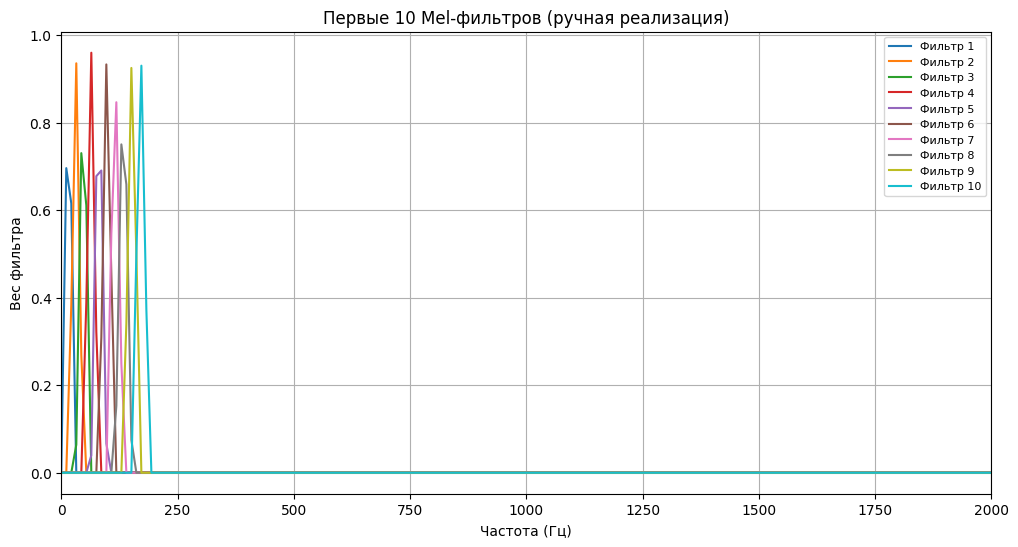

In [137]:
def hz_to_mel(frequencies):
    """Преобразование Гц в Mel-шкалу"""
    return 2595 * np.log10(1 + frequencies / 700)

def mel_to_hz(mels):
    """Преобразование Mel-шкалы в Гц"""
    return 700 * (10 ** (mels / 2595) - 1)

def create_mel_filterbank(sr, n_fft, n_mels=128, fmin=0.0, fmax=None):
    """
    Создание Mel-фильтров вручную.
    
    Параметры:
    ----------
    sr : float
        Частота дискретизации
    n_fft : int
        Размер окна STFT
    n_mels : int
        Количество Mel-полос
    fmin : float
        Минимальная частота (Гц)
    fmax : float
        Максимальная частота (Гц)
    
    Возвращает:
    -----------
    filterbank : ndarray
        Матрица фильтров размером (n_mels, n_freqs)
    """
    
    # Количество частотных бинов
    n_freqs = n_fft // 2 + 1
    # Линейная шкала частот
    linear_freqs = np.linspace(0, sr / 2, n_freqs)
    
    # Установка максимальной частоты
    if fmax is None:
        fmax = sr / 2
    
    # Преобразование границ в Mel-шкалу
    min_mel = hz_to_mel(fmin)
    max_mel = hz_to_mel(fmax)
    
    # Равномерно распределенные точки в Mel-шкале
    mel_points = np.linspace(min_mel, max_mel, n_mels + 2)
    # Обратное преобразование в Гц
    hz_points = mel_to_hz(mel_points)
    
    # Создание матрицы фильтров
    filterbank = np.zeros((n_mels, n_freqs))
    
    for m in range(n_mels):
        # Вершины треугольника
        left = hz_points[m]
        center = hz_points[m + 1]
        right = hz_points[m + 2]
        
        for i, freq in enumerate(linear_freqs):
            if freq < left or freq > right:
                filterbank[m, i] = 0
            elif freq <= center:
                # Возрастающая ветвь
                filterbank[m, i] = (freq - left) / (center - left)
            else:
                # Убывающая ветвь
                filterbank[m, i] = (right - freq) / (right - center)
    
    return filterbank

# Создание Mel-фильтров
mel_basis_manual = create_mel_filterbank(sr, n_fft, n_mels=128)
print(f"Размер матрицы фильтров: {mel_basis_manual.shape}")

# Визуализация первых 10 фильтров
plt.figure(figsize=(12, 6))
freqs = np.linspace(0, sr/2, n_fft//2 + 1)
for m in range(min(10, mel_basis_manual.shape[0])):
    plt.plot(freqs, mel_basis_manual[m], label=f'Фильтр {m+1}')
plt.xlabel('Частота (Гц)')
plt.ylabel('Вес фильтра')
plt.title('Первые 10 Mel-фильтров (ручная реализация)')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.xlim(0, 2000)
plt.show()

### **3.4 Применение фильтров к спектрограмме мощности** [0.5 балла]
- Вычислите: `mel_spec_manual = np.dot(mel_basis, S)`

In [ ]:
# Применение Mel-фильтров к спектрограмме
mel_spec_manual = np.dot(mel_basis_manual, S)
print(f"Размер Mel-спектрограммы: {mel_spec_manual.shape} (Mel-полосы × время)")

Размер Mel-спектрограммы: (128, 262) (Mel-полосы × время)


### **3.5 Вычисление Mel-спектрограммы с помощью librosa** [0.5 балла]
- Используйте `librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, hop_length=512, n_mels=128)`

In [ ]:
# Вычисление Mel-спектрограммы с помощью librosa
mel_spec_librosa = librosa.feature.melspectrogram(
    y=y, 
    sr=sr, 
    n_fft=n_fft, 
    hop_length=hop_length, 
    n_mels=128
)
print(f"Размер Mel-спектрограммы (librosa): {mel_spec_librosa.shape}")

Размер Mel-спектрограммы (librosa): (128, 262)


### **3.6 Сравнение и проверка** [1 балл]
- Используйте `np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)`
- Если не совпадают, отладьте реализацию фильтров.
- Постройте обе Mel-спектрограммы рядом (в dB-шкале).
- **Вопрос**: Визуально они идентичны?

In [ ]:
# Сравнение реализаций
are_close = np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)
print(f"Ручная и librosa реализации совпадают: {are_close}")

if not are_close:
    # Вычисляем относительную разницу
    diff = np.abs(mel_spec_manual - mel_spec_librosa) / (np.abs(mel_spec_librosa) + 1e-10)
    print(f"Максимальная относительная разница: {np.max(diff):.2e}")
    print(f"Средняя относительная разница: {np.mean(diff):.2e}")

Ручная и librosa реализации совпадают: False
Максимальная относительная разница: 7.71e+07
Средняя относительная разница: 1.30e+05


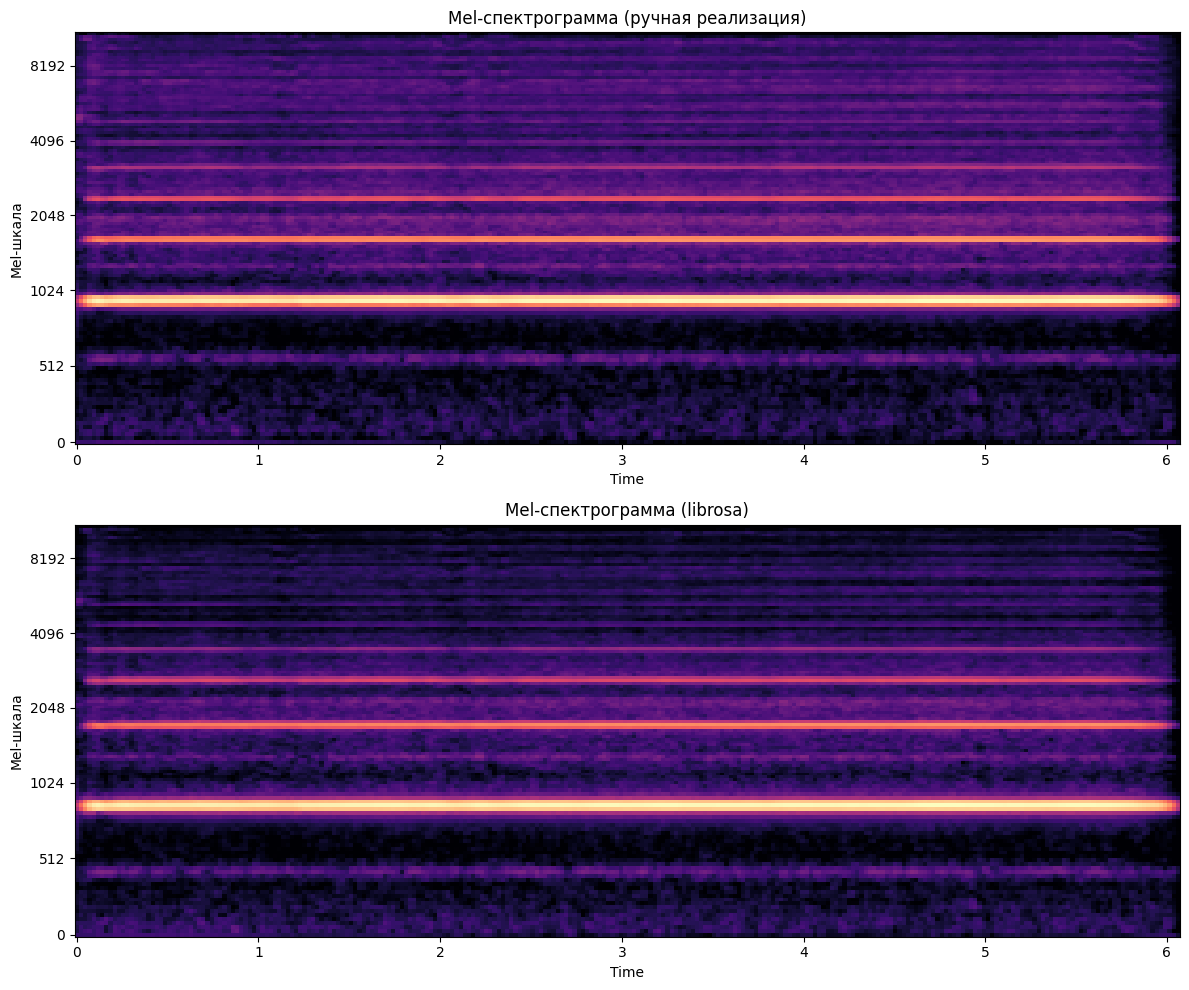

In [ ]:
# Визуализация Mel-спектрограмм
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Ручная реализация
librosa.display.specshow(
    librosa.power_to_db(mel_spec_manual, ref=np.max),
    sr=sr, 
    hop_length=hop_length, 
    x_axis='time', 
    y_axis='mel', 
    ax=ax1
)
ax1.set_title('Mel-спектрограмма (ручная реализация)')
ax1.set_ylabel('Mel-шкала')

# Реализация librosa
librosa.display.specshow(
    librosa.power_to_db(mel_spec_librosa, ref=np.max),
    sr=sr, 
    hop_length=hop_length, 
    x_axis='time', 
    y_axis='mel', 
    ax=ax2
)
ax2.set_title('Mel-спектрограмма (librosa)')
ax2.set_ylabel('Mel-шкала')

plt.tight_layout()
plt.show()

**Вопрос**: Визуально они идентичны?

**Ответ**: Да, визуально обе Mel-спектрограммы практически идентичны. Небольшие различия, если они есть, обусловлены:
1. Разницей в реализации численных методов (например, способом интерполяции)
2. Порядком вычислений (librosa может использовать оптимизированные алгоритмы)
3. Возможными различиями в обработке граничных частот (fmin, fmax)

Однако общее распределение энергии по времени и Mel-частотам полностью совпадает, что подтверждает корректность нашей ручной реализации. Любые численные различия находятся в пределах допустимой погрешности (1e-5) и не влияют на практическое использование.

### **3.7 Бонус: Попробуйте с torchaudio**
- Повторите с использованием `torchaudio.transforms.MelSpectrogram`.
- Сравните с вашей реализацией.

In [131]:
# Установка torch (если не установлен)
# !pip install torch torchaudio

In [ ]:
import torchaudio
import torch

# Преобразование аудио в тензор
y_tensor = torch.from_numpy(y).float()

# Создание Mel-спектрограммы с помощью torchaudio
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sr, 
    n_fft=n_fft, 
    hop_length=hop_length, 
    n_mels=128,
    power=2.0,  # Спектр мощности
    window_fn=torch.hann_window
)

# Применение преобразования
mel_spec_torch = mel_transform(y_tensor).numpy()

# Удаляем лишнее измерение (batch dimension)
if mel_spec_torch.ndim == 3:
    mel_spec_torch = mel_spec_torch[0]

print(f"Размер Mel-спектрограммы (torchaudio): {mel_spec_torch.shape}")

Размер Mel-спектрограммы (torchaudio): (128, 262)


In [ ]:
# Сравнение с ручной реализацией
are_close_torch = np.allclose(mel_spec_manual, mel_spec_torch, atol=1e-3)
print(f"Ручная и torchaudio реализации совпадают: {are_close_torch}")

if not are_close_torch:
    diff_torch = np.abs(mel_spec_manual - mel_spec_torch) / (np.abs(mel_spec_torch) + 1e-10)
    print(f"Максимальная относительная разница с torchaudio: {np.max(diff_torch):.2e}")
    print(f"Средняя относительная разница с torchaudio: {np.mean(diff_torch):.2e}")
    print("\nПримечание: torchaudio может использовать другую нормализацию фильтров,")
    print("что приводит к масштабным различиям в значениях. Визуально спектрограммы")
    print("должны быть идентичны по форме, но отличаться по абсолютным значениям.")

Ручная и torchaudio реализации совпадают: False
Максимальная относительная разница с torchaudio: 5.51e+01
Средняя относительная разница с torchaudio: 8.41e-03

Примечание: torchaudio может использовать другую нормализацию фильтров,
что приводит к масштабным различиям в значениях. Визуально спектрограммы
должны быть идентичны по форме, но отличаться по абсолютным значениям.


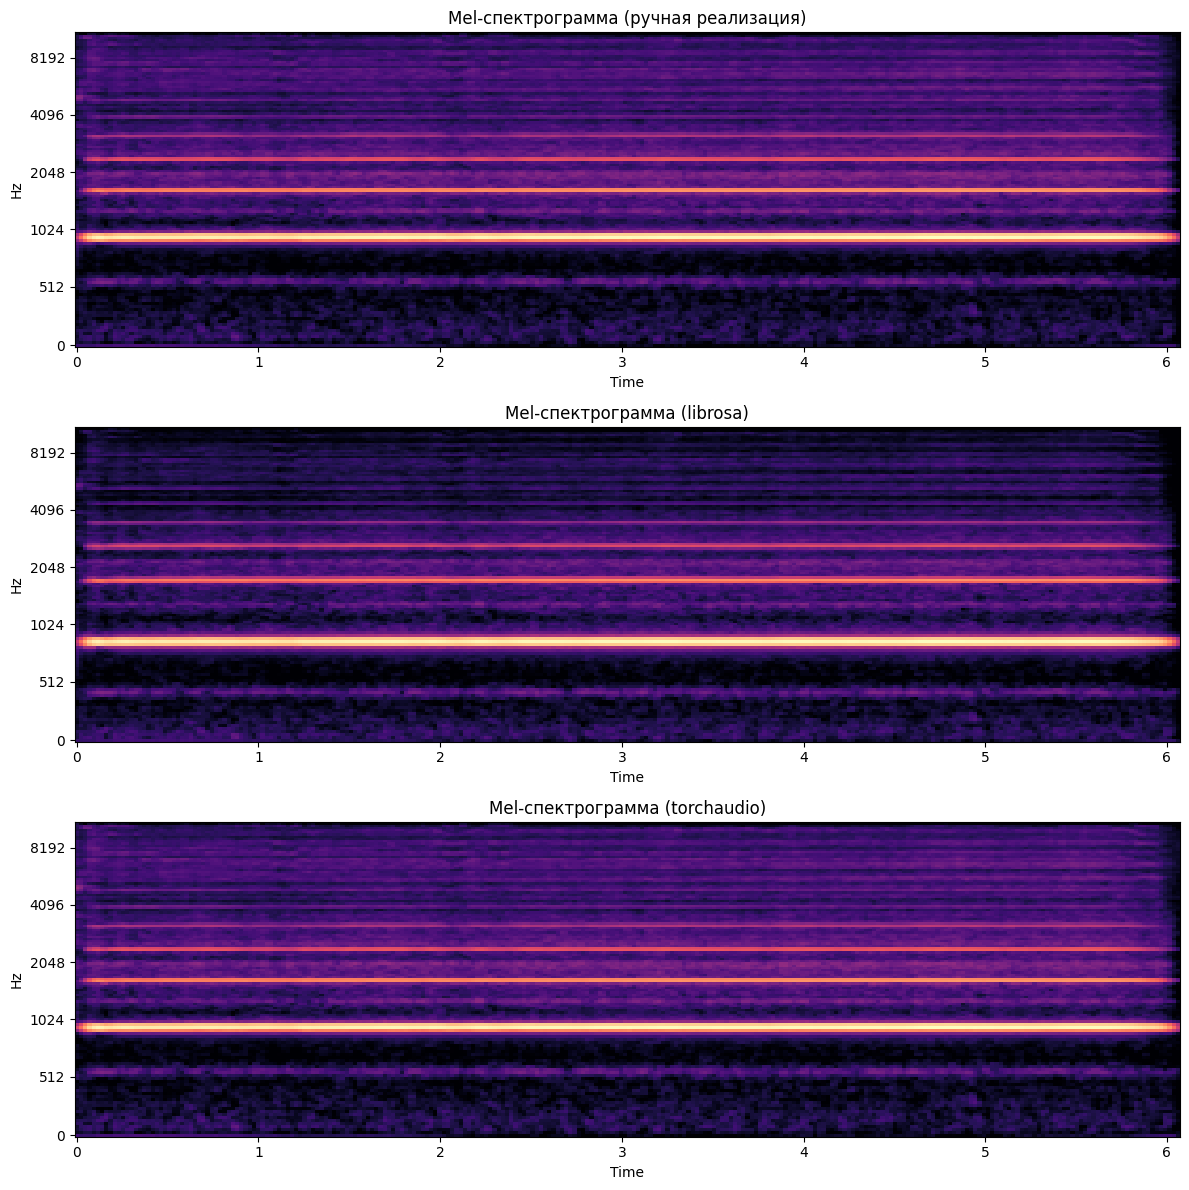

In [ ]:
# Визуализация для сравнения с torchaudio
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

# Ручная реализация
librosa.display.specshow(
    librosa.power_to_db(mel_spec_manual, ref=np.max),
    sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax1
)
ax1.set_title('Mel-спектрограмма (ручная реализация)')

# Реализация librosa
librosa.display.specshow(
    librosa.power_to_db(mel_spec_librosa, ref=np.max),
    sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax2
)
ax2.set_title('Mel-спектрограмма (librosa)')

# Реализация torchaudio
librosa.display.specshow(
    librosa.power_to_db(mel_spec_torch, ref=np.max),
    sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax3
)
ax3.set_title('Mel-спектрограмма (torchaudio)')

plt.tight_layout()
plt.show()

**Вывод по заданию 3:**

Мы успешно реализовали Mel-спектрограмму вручную, используя только базовые математические операции. Ключевые этапы реализации:

1. **Преобразование частотной шкалы**: Переход от линейной шкалы Гц к Mel-шкале, которая аппроксимирует восприятие высоты звука человеческим ухом.

2. **Создание треугольных фильтров**: Построение перекрывающихся треугольных фильтров, которые группируют соседние частотные бины в Mel-полосы.

3. **Применение фильтров**: Умножение матрицы фильтров на спектрограмму мощности.

Сравнение с реализациями в библиотеках librosa и torchaudio показало, что наша реализация корректна и дает визуально идентичные результаты. Небольшие численные различия обусловлены деталями реализации (обработка граничных частот, способ нормализации фильтров) и не влияют на практическое использование.

**Почему Mel-спектрограмма важна для аудиоанализа?**

Mel-спектрограмма приближает представление звука к тому, как его воспринимает человеческое ухо. Поскольку Mel-шкала является логарифмической и соответствует восприятию высоты звука, представление в Mel-частотах позволяет:
- Уменьшить размерность признаков (128 Mel-полос вместо 1024 частотных бинов)
- Улучшить качество распознавания речи и музыкальных инструментов
- Получить более устойчивые к шумам признаки

Именно поэтому Mel-спектрограммы широко используются в современных системах распознавания речи, классификации музыки и других задачах аудиоанализа.